# Twin Delayed DDPG (TD3)

The TD3 algorithm as given in the [original paper](https://arxiv.org/abs/1802.09477) is provided below. The algorithm incorporates several mechanism to increase training stability and efficiency by not only reducing the effect of variance on the training performance but also the error and variance originating from the bootstrapping procedure

1. **Clipped Double Q-Learning** (red) - maintaining two separate Q-value (critic) networks and use the minimum estimation out of the two to form a pessimistic bound for the TD target
2. **Target networks** (blue) - to stabilize training as explained in the DQN papers. To further increase the training stability, the target networks are slowly updated toward the current network after a short delay (the next mechanism). The purpose of each network and their update frequencies are as follows
    - The online actor network generates the online action taken to observe and store a new transition tuple $(s,a,r,s')$ in the buffer $\mathcal{D}$. The parameter update of this network is delayed and happens once every d time steps $t \text{ mod } d$
    - The offline actor network generate a stable and optimal target action in state s'. To smooth the policy over a small neighborhood of the optimal action, a **clipped Gaussian noise $\epsilon$** is added to this optimal action to create $\tilde a$
    - The parameters of the online critics are updated at every time step $t=1 \text{ to } T$ and serves as the weight targets for the offline target critics
    - The offline target critics are used as the TD target estimation, which is used for updating the parameters of the online critics by means of minimizing the MSE between online estimation of $Q(s,a)$ and **clipped offline bootstrap TD target $r+\gamma \min_{i=1,2}Q_{\theta_i'}(s',\tilde a)$**
3. **Delayed actor updates** (green) - to allow the critic network some time to converge to a more accurate estimation before updating the actor network and the target networks, both critics and targets alike.

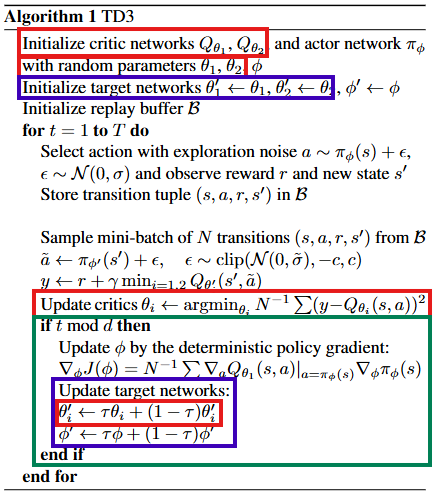

## Library imports

In [1]:
import gymnasium as gym
import torch
from torch import nn
import torch.optim as optim
from torch.distributions import Normal      # normal dist

import numpy as np
import matplotlib.pyplot as plt
from statistics import mean, stdev
import random

import re, os, json, time
from datetime import datetime
from collections import deque
from tqdm import tqdm

# --- import the custom-made TD3 algorithm
import sys
sys.path.insert(0,'..')
from algos import TD3

## Parameter and Class Definition

In [2]:
def set_global_seed(env: gym.Env, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    env.action_space.seed(seed)

## TD3 training

In [3]:
model_registry = {
    'TD3_v0': {
        'actor_config': [64,64],
        'critic_config': [64,64]
    }
}

MODEL_NAME = 'TD3_v0'
ALPHA1 = 5e-3
ALPHA2 = 5e-3
BETA = 5e-3
GAMMA = 0.99
TAU_C = 5e-2
TAU_A = 5e-2
SIGMA = 0.2
CLIP = 0.5

BUFFER_SIZE = 10000
BUFFER_INIT = 1000
BATCH_SIZE = 64

UPDATE_FREQ = 2
TRAIN_ITER = 100_000
TRAIN_CRIT = {'pass_limit':10, 'pass_score': 9_000, 'coeff_var_limit': 0.1}
RESULT_FOLDER = 'invdoublepend_TD3_results'


run_00012: 100%|███████████████████████████████████████████| 100000/100000 [03:40<00:00, 454.54it/s]


Training terminated due to episode limit, best model saved at episode   161 with evaluate reward (9353.177, 3.409)
Best model episode 161


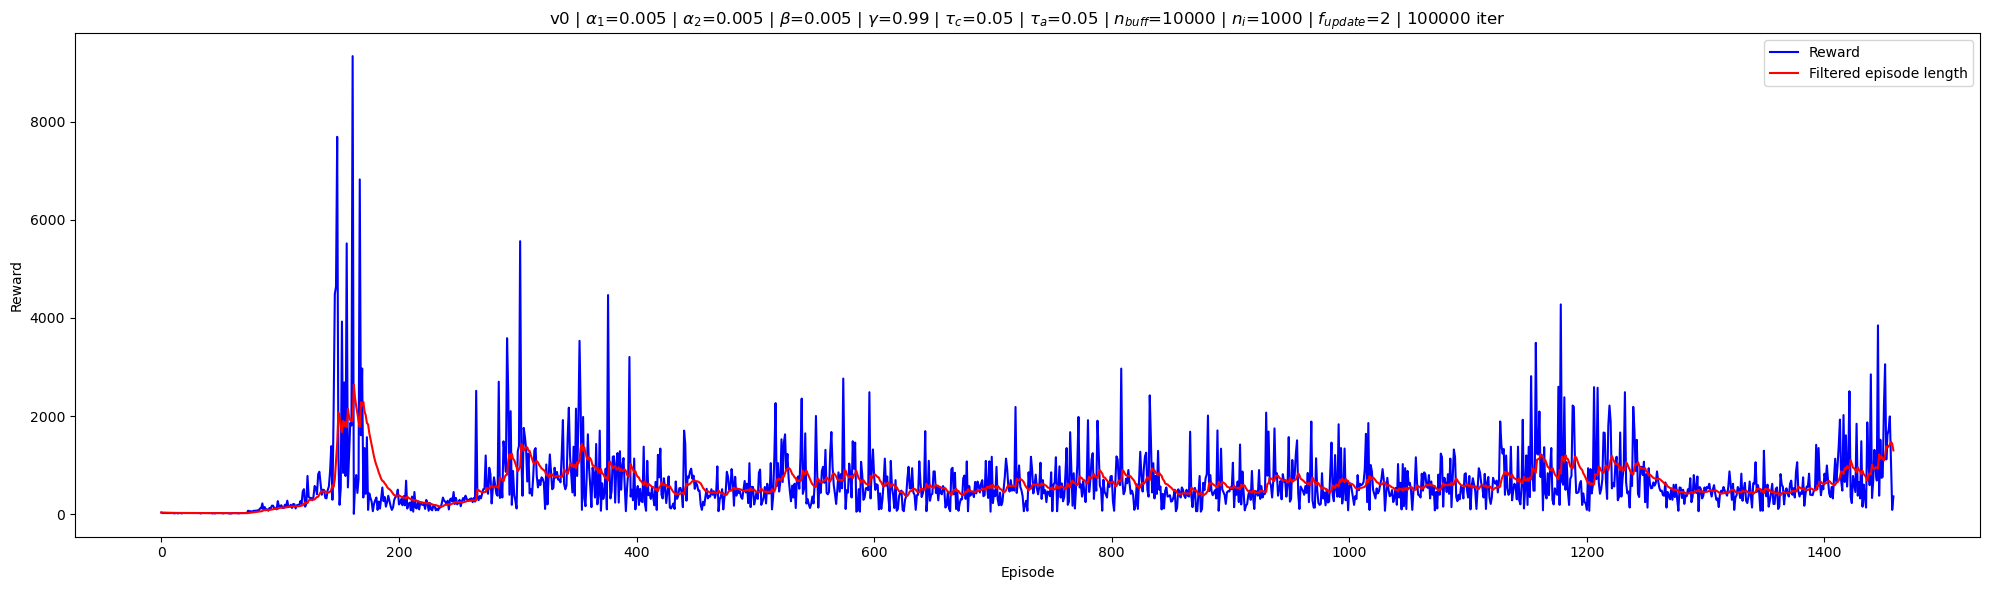

In [ ]:
env = gym.make("InvertedDoublePendulum-v5")
for i in range(1):
    seed = np.random.randint(1,100)
    # set_global_seed(env,seed=seed)
  
    TD3_experiment = TD3(model_name=MODEL_NAME, model_registry=model_registry, env=env,
                    alpha1=ALPHA1,alpha2=ALPHA2,beta=BETA,gamma=GAMMA,
                    tau_c=TAU_C,tau_a=TAU_A,sigma=SIGMA,clip=CLIP,
                    buffer_size=BUFFER_SIZE,buffer_init=BUFFER_INIT,
                    batch_size=BATCH_SIZE, update_f=UPDATE_FREQ, iter=TRAIN_ITER,
                    train_crit=TRAIN_CRIT,
                    result_folder=RESULT_FOLDER,
                    cuda_enabled=False,
                    seed=seed)
                
    TD3_experiment.train()